In [1]:
print("kernel alive")

kernel alive


In [2]:
import pickle
from experiments.robot.libero.gen_config import GenerateConfig
from experiments.robot.openvla_utils import get_action_head, get_processor, get_proprio_projector, get_vla, get_vla_action
from prismatic.vla.constants import NUM_ACTIONS_CHUNK, PROPRIO_DIM

2026-06-20 19:50:13.814176: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-20 19:50:13.852762: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-20 19:50:13.852798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-20 19:50:13.853954: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-20 19:50:13.860323: I tensorflow/core/platform/cpu_feature_guar

Using LIBERO constants:
  NUM_ACTIONS_CHUNK = 8
  ACTION_DIM = 7
  PROPRIO_DIM = 8
  ACTION_PROPRIO_NORMALIZATION_TYPE = bounds_q99
If needed, manually set the correct constants in `prismatic/vla/constants.py`!


2026-06-20 19:50:23.699431: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-20 19:50:23.752896: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# Instantiate config (see class GenerateConfig in experiments/robot/libero/run_libero_eval.py for definitions)
cfg = GenerateConfig(
    pretrained_checkpoint = "openvla_7b_oft_finetuned",
    use_l1_regression = True,
    use_diffusion = False,
    use_film = False,
    num_images_in_input = 2,
    use_proprio = True,
    load_in_8bit = False,
    load_in_4bit = True,
    center_crop = True,
    num_open_loop_steps = NUM_ACTIONS_CHUNK,
    unnorm_key = "libero_spatial_no_noops",
)

In [4]:
# Load OpenVLA-OFT policy and inputs processor
vla = get_vla(cfg)
processor = get_processor(cfg)

Instantiating pretrained VLA policy...
load_in_4bit: True
load_in_8bit: False
quantization_config: BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



Loading checkpoint shards: 100%|██████████| 4/4 [00:16<00:00,  4.10s/it]


In [5]:
# Load MLP action head to generate continuous actions (via L1 regression)
action_head = get_action_head(cfg, llm_dim=vla.llm_dim)

# Load proprio projector to map proprio to language embedding space
proprio_projector = get_proprio_projector(cfg, llm_dim=vla.llm_dim, proprio_dim=PROPRIO_DIM)

In [6]:
with open("experiments/robot/libero/sample_libero_spatial_observation.pkl", "rb") as file:
    observation = pickle.load(file)

06/20 [20:00:30] INFO     | >> generated new fontManager                                       ]8;id=908857;file:///home/s2fli/miniconda/envs/openvla-oft/lib/python3.10/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=810150;file:///home/s2fli/miniconda/envs/openvla-oft/lib/python3.10/site-packages/matplotlib/font_manager.py#1639\1639]8;;\

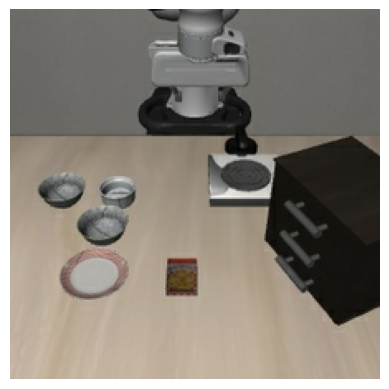

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

plt.imshow(observation['full_image'])
plt.axis('off')
plt.show()

In [8]:
# Generate robot action chunk (sequence of future actions)
actions = get_vla_action(cfg, vla, processor, observation, observation["task_description"], action_head, proprio_projector)
print("Generated action chunk:")
for act in actions:
    print(act)

Generated action chunk:
[0.153 0.034 0.050 -0.004 0.037 0.006 1.008]
[0.246 0.078 0.104 -0.010 0.039 0.005 1.008]
[0.356 0.166 0.136 -0.009 0.044 0.002 1.008]
[0.515 0.254 0.162 -0.003 0.052 0.003 1.008]
[0.665 0.325 0.167 -0.002 0.051 0.006 1.008]
[0.799 0.404 0.148 -0.003 0.026 0.005 1.008]
[0.842 0.455 0.106 -0.003 0.006 0.007 1.008]
[0.842 0.486 0.072 -0.002 0.002 0.013 1.000]
